<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Pr%C3%A1ctica_25_Regresi%C3%B3n_con_Datos_Categ%C3%B3ricos_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** Regresión lineal con datos categóricos: Costos, Localidades y Salarios**

📌 Objetivos de la Práctica:
Al finalizar esta práctica, los estudiantes serán capaces de:

- Codificar variables categóricas usando one-hot encoding con K-1 para problemas de regresión
- Realizar AED
- Construir un modelo de regresión con variables dummy
- Interpretar los resultados de los coeficientes
- Analizar los resultados de los errores residuales
- Calcular el desempeño del modelo de regresión.

Problema: Se podría argumentar que el salario está relacionado con el costo de la educación. Por lo tanto, para analizar este argumentos veremos qué sucede cuando usamos las variables independientes cost y location.

# 1. Carga de datos

Carga el conjunto de datos college.csv, que está en campus virtual, en un dataframe. Elige de este conjunto las columnas salary (variable dependiente), cost(variable independiente - numérica) y location (variable independiente categórica).

Realiza lo siguiente:

*   Convierte si es necesario la variable location a tipo de dato categórico
*   Usa la instrucción describe() en las variables salary y cost
* Cuenta la cantidad de datos que hay por categoría en location
* Convierte la variable location usando one-hot encoding



In [21]:
# Google Drive para acceder a los archivos almacenados
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# Importamos la librería pandas para trabajar con datos tabulares
import pandas as pd

# Cargamos el archivo CSV completo desde Google Drive
df = pd.read_csv('/content/drive/MyDrive/Unidad03/college-Práctica 25.csv')

# Mostramos las primeras filas del DataFrame para ver todas las columnas disponibles
print("Primeras 5 filas del conjunto de datos completo:")
print(df.head())

Primeras 5 filas del conjunto de datos completo:
   id                                         name  salary    cost   public  \
0   1  Massachusetts Institute of Technology (MIT)  119000  189300  Private   
1   2                           Harvard University  121000  189600  Private   
2   3                            Dartmouth College  123000  188400  Private   
3   4                         Princeton University  123000  188700  Private   
4   5                              Yale University  110000  194200  Private   

  location  
0       NE  
1       NE  
2       NE  
3       NE  
4       NE  


In [23]:
# Seleccionamos las columnas salary y cost para describir su distribución
print("Estadísticas de 'salary':")
print(df['salary'].describe())

print("\nEstadísticas de 'cost':")
print(df['cost'].describe())

Estadísticas de 'salary':
count        85.000000
mean      95898.823529
std       11937.121912
min       74900.000000
25%       87100.000000
50%       93200.000000
75%      105000.000000
max      123000.000000
Name: salary, dtype: float64

Estadísticas de 'cost':
count        85.000000
mean     142434.470588
std       53913.064578
min       18260.000000
25%       84670.000000
50%      169200.000000
75%      188700.000000
max      227300.000000
Name: cost, dtype: float64


In [24]:
# Contamos cuántas observaciones hay en cada categoría de 'location'
location_counts = df['location'].value_counts()

print("Cantidad de universidades por región:")
print(location_counts)

Cantidad de universidades por región:
location
NE    25
W     21
S     20
MW    19
Name: count, dtype: int64


In [25]:
# Importamos OneHotEncoder de scikit-learn
from sklearn.preprocessing import OneHotEncoder

# Creamos un codificador que:
# - sparse_output=False para obtener un array denso
# - drop='first' para eliminar la primera categoría y evitar multicolinealidad
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Ajustamos y transformamos la columna 'location'
location_encoded = encoder.fit_transform(df[['location']])

# Obtenemos nombres de las nuevas columnas dummy
columns_dummy = encoder.get_feature_names_out(['location'])

# Convertimos el array codificado a un DataFrame con nombres de columnas
df_dummy = pd.DataFrame(location_encoded, columns=columns_dummy)

# Concatenamos el DataFrame original con las columnas dummy
df = pd.concat([df, df_dummy], axis=1)

# Mostramos las primeras filas del DataFrame final
print("DataFrame con columnas dummy de 'location':")
print(df.head())

DataFrame con columnas dummy de 'location':
   id                                         name  salary    cost   public  \
0   1  Massachusetts Institute of Technology (MIT)  119000  189300  Private   
1   2                           Harvard University  121000  189600  Private   
2   3                            Dartmouth College  123000  188400  Private   
3   4                         Princeton University  123000  188700  Private   
4   5                              Yale University  110000  194200  Private   

  location  location_NE  location_S  location_W  
0       NE          1.0         0.0         0.0  
1       NE          1.0         0.0         0.0  
2       NE          1.0         0.0         0.0  
3       NE          1.0         0.0         0.0  
4       NE          1.0         0.0         0.0  


# 2. Análisis Exploratorio de los Datos

Realiza un análisis exploratorio de los datos y discute lo que observas en cada gráfica.


*   Crea un histograma de la columna salary. Discute lo que observas
* Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas
* Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas




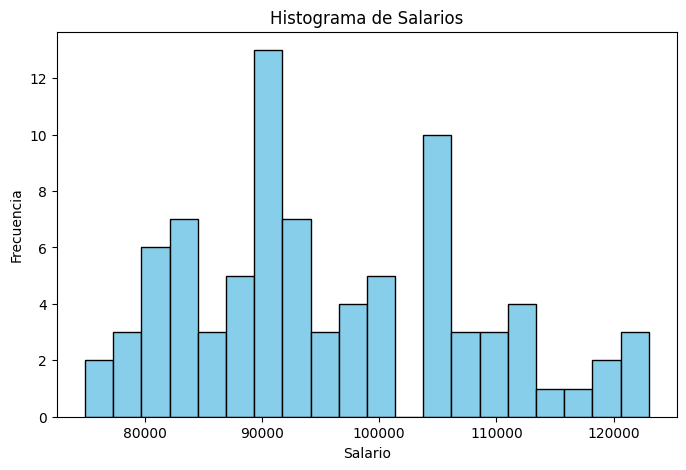

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['salary'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histograma de Salarios')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.show()

En el histograma de la columna salary vemos que la mayoría de las universidades tienen salarios en un rango de 90 000 – 92 000 dólares. Hay algunas pocas que pagan menos de 80 000 y unas cuantas que llegan hasta más de 120 000. Pero la mayoría está pegada al centro.

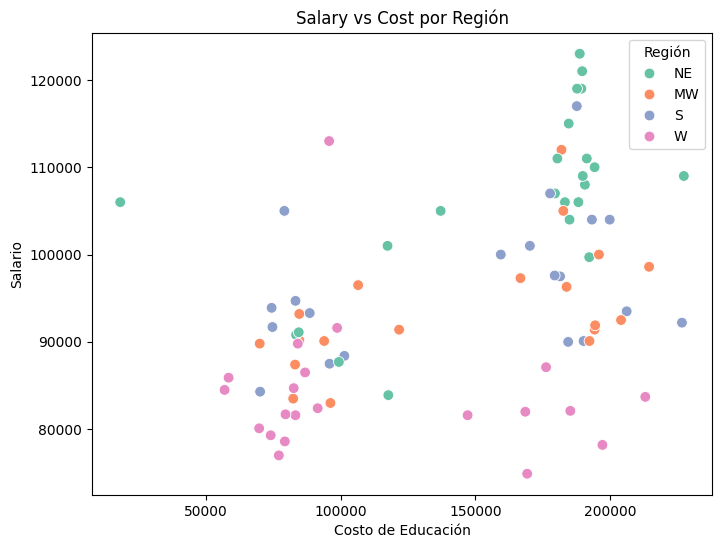

In [27]:
# Diagrama de dispersión salary vs cost coloreado por location
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='cost',
    y='salary',
    hue='location',
    palette='Set2',
    s=60
)
plt.title('Salary vs Cost por Región')
plt.xlabel('Costo de Educación')
plt.ylabel('Salario')
plt.legend(title='Región')
plt.show()

El scatterplot muestra una tendencia general de relación positiva entre costo y salario: las universidades con costos más altos tienden a ofrecer salarios más elevados. Además, cada región presenta su propio agrupamiento:

NE (verde): concentra varias universidades con costos altos (>180 000) y salarios altos (>105 000).

MW (naranja): dispersión amplia, algunas con costos medios y salarios moderados.

S (morado): más variedad, pero varios puntos en costos bajos y salarios bajos.

W (rosa): algunos outliers en costos altos (>200 000) con salarios moderados.
Esta diferenciación sugiere que la región geográfica influye en la estructura costo–salario.

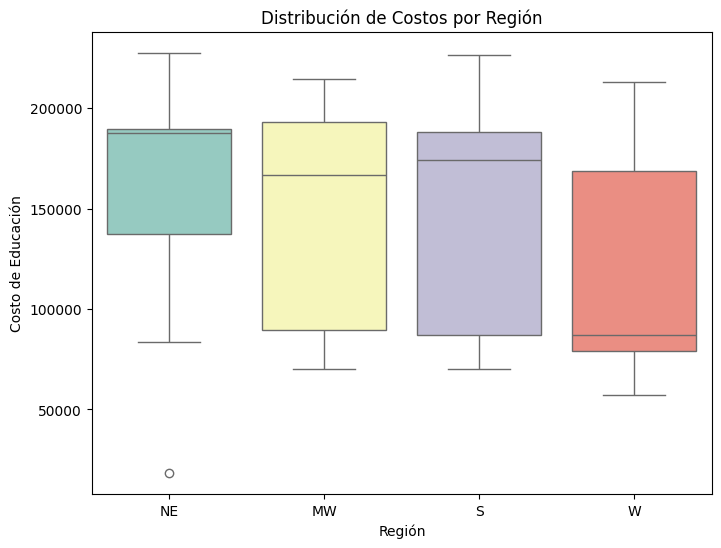

In [28]:
#Boxplot de cost por location
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='location',
    y='cost',
    hue='location',
    palette='Set3',
    dodge=False
)
plt.title('Distribución de Costos por Región')
plt.xlabel('Región')
plt.ylabel('Costo de Educación')
plt.legend([],[], frameon=False)  # Oculta la leyenda redundante
plt.show()

El boxplot permite comparar la distribución de costos entre regiones:

NE: mediana alta (~190 000) y rango intercuartílico estrecho, indicando costos consistentemente altos.

MW: mediana ligeramente menor (170 000) y rango más amplio, con varios outliers por debajo (70 000–80 000).

S: rango intercuartílico similar a MW, pero medianas alrededor de 175 000.

W: mediana más baja (~85 000) y una dispersión amplia, sugiriendo gran variabilidad de costos.

RESUMEN:

Noreste: cobra caro casi siempre.

Medio Oeste y Sur: cobran en rangos medios, pero con altibajos.

Oeste: tiene de todo: algunas cobran bajo y otras caro.

En pocas palabras: cada zona tiene su propio estilo de precios, y el Oeste es el más variado.

# 3. Construcción del modelo de regresión

- Construye el modelo de regresión usando los datos de salario, costo y location. Recuerda que esta última debe ser en su versión codificada con one-hot encoding.
- Imprime los coeficientes e interpreta qué significan cuando se sustituyen valores en costo, y location (versión codificada). Si no recuerdas cómo se hace esta interpretación consulta los videos.


In [29]:
# Importamos la librería para regresión lineal
from sklearn.linear_model import LinearRegression

# Definimos las variables independientes (cost + dummies de location)
X = df[['cost', 'location_NE', 'location_S', 'location_W']]

# Variable dependiente
y = df['salary']

# Creamos y entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Imprimimos el intercepto y los coeficientes
print("Intercepto (β₀):", modelo.intercept_)
print("Coeficientes:")
for nombre, coef in zip(X.columns, modelo.coef_):
    print(f"  {nombre}: {coef}")

Intercepto (β₀): 84988.71622754404
Coeficientes:
  cost: 0.06051753417141942
  location_NE: 12032.819692403562
  location_S: 2800.345026332499
  location_W: -7721.420103045976


Cuando conviertes una variable categórica como location en variables dummy usando One-Hot Encoding con la opción drop='first', lo que hace Python es generar columnas para todas las regiones EXCEPTO UNA. Esa “una” que se queda afuera se usa como base o referencia. En este caso, MW (Midwest) es la que queda como base porque es la primera en orden alfabético

Intercepto: Corresponde a una universidad en Midwest (MW) con costo = 0 (base de comparación).

location_NE: Cuánto más (o menos) se espera de salario si la universidad está en el Noreste, comparando con el Midwest.

location_S: Cuánto más (o menos) paga el Sur respecto al Midwest.

location_W: Cuánto más (o menos) paga el Oeste respecto al Midwest.

Intercepto (β₀): 84,988.72 → Salario base en MW con costo = 0.

cost: 0.0605 → Por cada dólar extra en costo, el salario sube 0.0605 dólares.

location_NE: 12,032.82 → Una universidad en el Noreste paga, en promedio, 12 mil dólares más que una igualita (mismo costo) en Midwest.

location_S: 2,800.35 → En el Sur, el salario sube 2,800 dólares sobre el Midwest.

location_W: –7,721.42 → El Oeste paga 7,700 dólares MENOS que el Midwest, todo lo demás igual.

Entonces, si una universidad está en MW, las tres columnas dummy serán 0, y la predicción sólo usa intercepto + cost. Si está en NE, la columna NE vale 1 y las otras dos 0, por lo que el modelo suma esos 12 mil extra. Así con las otras regiones.

# 4. Análisis de Residuos

- Construyen una visualización de predicciones (salario estimado) vs valores reales (salario real).
- Crea una gráfica de los errores residuales. Discute lo que observas

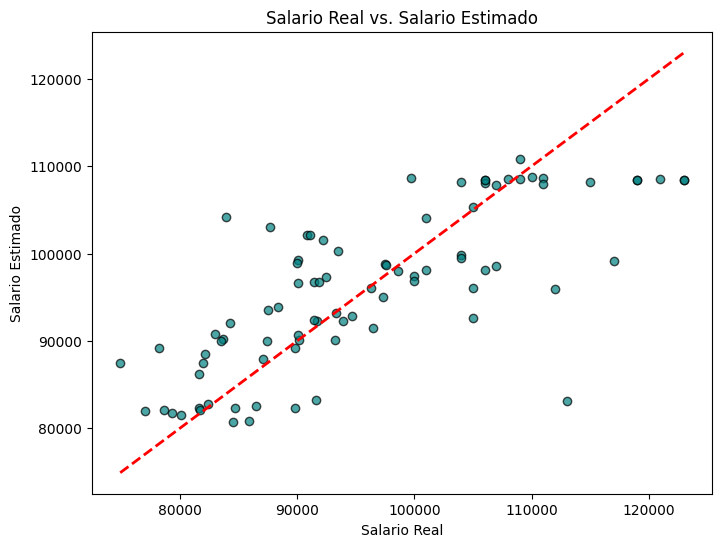

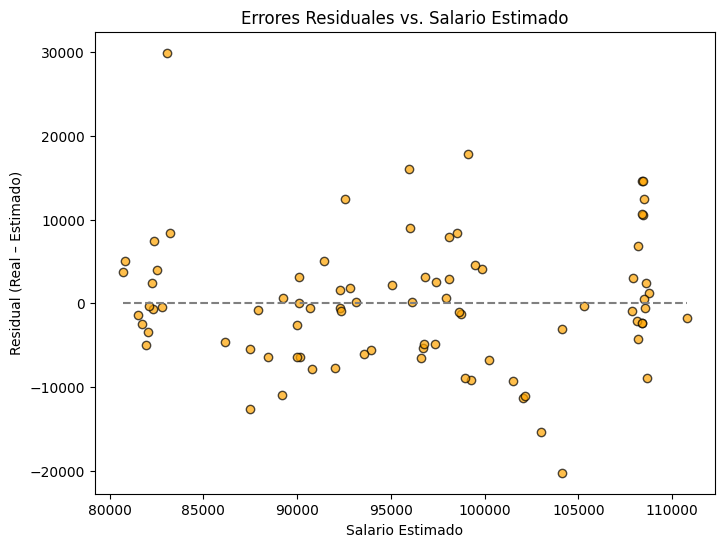

In [30]:
# Importar librerías para visualización y cálculos
import matplotlib.pyplot as plt
import numpy as np

# Paso 1: Generar predicciones
y_pred = modelo.predict(X)

# Paso 2: Visualización de predicciones vs. valores reales
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='teal', edgecolor='k', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.title('Salario Real vs. Salario Estimado')
plt.xlabel('Salario Real')
plt.ylabel('Salario Estimado')
plt.show()

# Paso 3: Cálculo de errores residuales
residuals = y - y_pred

# Paso 4: Gráfica de errores residuales vs. predicciones
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='orange', edgecolor='k', alpha=0.7)
plt.hlines(0, xmin=y_pred.min(), xmax=y_pred.max(), linestyles='dashed', colors='gray')
plt.title('Errores Residuales vs. Salario Estimado')
plt.xlabel('Salario Estimado')
plt.ylabel('Residual (Real – Estimado)')
plt.show()

# **Interpretación de “Salario Real vs. Salario Estimado”**

La línea punteada roja es donde “Real = Estimado”. Idealmente todos los puntos deberían caer sobre esa línea.

Vemos que muchos están cerca, pero hay algunos puntos dispersos arriba y abajo.

Puntos por encima de la línea: el modelo subestimó el salario real (real > estimado).

Puntos por debajo: el modelo sobreestimó (real < estimado).

Hay un grupo junto a los 105 000–110 000 donde el modelo ajusta muy bien. Sin embargo, en rangos bajos (80 000) y muy altos (120 000) la dispersión es mayor, lo que indica menos precisión en extremos.

# **Interpretación de “Errores Residuales vs. Salario Estimado”**

El eje horizontal muestra el salario que el modelo predijo; el vertical, la diferencia real – estimado. La línea gris punteada en cero es el punto donde no hay error.

Observamos:

Los residuos se distribuyen alrededor de cero sin un patrón obvio de curva o tendencia ascendente/descendente.

Hay algunos residuos grandes (hasta +30 000 y –20 000), lo que significa que para ciertos casos el modelo falla fuerte.

No aparece una varianza creciente ni una varianza decreciente, lo cual está bien: la dispersión de errores es relativamente constante en todo el rango de predicciones.

Hasta aqui el modelo funciona aceptable: predice bastante bien alrededor de valores medios, pero es menos confiable en los extremos, donde los errores pueden ser grandes.

# 5. Evalúa el modelo

- Calcula el MSE del modelo construido. Recuerda que usas el propio conjunto de datos (No hablamos nada de entrenamiento y test).
- Calcula el R² Score

Discute estos resultados obtenidos.

In [31]:
# Importar métricas de scikit-learn
from sklearn.metrics import mean_squared_error, r2_score

# Generar predicciones nuevamente
y_pred = modelo.predict(X)

# Calcular MSE (Mean Squared Error)
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

# Calcular R² Score
r2 = r2_score(y, y_pred)
print("R² Score:", r2)

MSE: 60480269.14657189
R² Score: 0.5705089716684086


MSE (604480269): Este número es muy grande, pero básicamente lo que nos dice es que las predicciones del modelo y los salarios reales sí tienen diferencias importantes. Si calculas la raíz cuadrada (√MSE ≈ 24,600), eso significa que, en promedio, el modelo se puede equivocar como 24 mil 600 dólares arriba o abajo en cada predicción de salario. No es un error bajo, pero tampoco es gigantesco para los rangos que tiene esta base.

R² Score (0.57): Este valor, redondeando, es como 57% de la diferencia entre los salarios de todas las universidades sí la logra explicar el modelo usando solo el costo y la región. El otro 43% depende de otras cosas que no estamos usando (quizá el prestigio, el tipo de carrera, etc.).

El modelo te ayuda a ver la tendencia general (como que pagar más se asocia a ganar más y que la región también importa), pero no es perfecto: hay varias universidades donde la predicción se queda lejos del valor real. Sirve para darse una idea, pero si queremos una predicción precisa para cualquier caso, hacen falta más datos o variables.

# 6. Realiza un análisis de varianza con stastmodel

Consulta esto aquí https://www.statsmodels.org/dev/examples/notebooks/generated/variance_components.html

In [32]:
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

# Asegura que 'location' sea string para la fórmula
df['loc_str'] = df['location'].astype(str)

# Definir componentes de varianza por región
vc = {"region": "0 + C(loc_str)"}

# Ajustar modelo con from_formula (no pasar reml ni intercept extra)
model_vc = MixedLM.from_formula(
    "salary ~ 1",
    vc_formula=vc,
    groups=np.ones(len(df), dtype=int),   # todos en un mismo grupo
    data=df
)
result_vc = model_vc.fit()

print(result_vc.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   salary       
No. Observations:    85        Method:               REML         
No. Groups:          1         Scale:                73184780.8511
Min. group size:     85        Log-Likelihood:       -886.8277    
Max. group size:     85        Converged:            Yes          
Mean group size:     85.0                                         
------------------------------------------------------------------
              Coef.     Std.Err.   z    P>|z|   [0.025    0.975]  
------------------------------------------------------------------
Intercept     95351.181 4703.669 20.272 0.000 86132.160 104570.202
region Var 85017438.469 8573.745                                  



# Intercept (≈ 95 351)
Este valor es la estimación de salario promedio general, sin considerar la región. Alrededor de 95 000 dólares es el salario medio de todas las universidades juntas.

# region Var (≈ 85 017 438)
Esta es la varianza atribuible a la diferencia entre regiones. En unidades de “dólares al cuadrado”, refleja cuánto varían los salarios medios de una región a otra.

# Scale (≈ 713 847 806)
Esta es la varianza residual, es decir, la variación de salarios dentro de cada región que no explica el modelo de componentes de varianza.

Para comparar:

La varianza entre regiones (85 millones) es mucho menor que la varianza residual (713 millones).

**Esto significa que la región sí influye en el salario promedio**, pero explica relativamente poco de toda la dispersión de salarios. La mayoría de la variación (713 M vs. 85 M) sucede por factores internos a cada región (universidades específicas, programas, reputación, empleabilidad, etc.), no solo por estar en NE, MW, S o W.